# Chapter 41 — Spring Element Materials
### *Modern Strain Gage Technology* — Companion Notebook

*A stronger material is not automatically a better transducer material — it is **modulus**, not strength, that sets the signal.*

Companion notebook to Chapter 41 — Spring Element Materials: The Modulus Problem and How to Solve It.

The material of a transducer spring element must satisfy several conflicting requirements simultaneously. It must have an elastic modulus low enough that the sensing section can be made thick and stable at the target strain, a yield strength high enough that the element stays elastic at overload, thermal conductivity high enough to carry gage self-heating away, and good machinability so the element can be finished to tight tolerances — plus low creep and hysteresis so the reading does not drift. No single material excels on all criteria, which is why the set of commonly used spring element materials is small and the choice between them is deliberate.

The central, counterintuitive lesson of the chapter is that a *stronger* material is not automatically a *better* transducer material. Strength sets overload capacity; **modulus** sets how much strain — and therefore how much signal — the element produces at a given load and geometry. Because section depth scales as $1/\sqrt{E}$, a lower-modulus alloy lets the sensing section be thicker, which reduces gage reinforcement, thermal gradients, and machining sensitivity all at once.

**This notebook demonstrates:**
1. Side-by-side comparison of elastic modulus, elastic strain capacity ($\sigma_y/E$), and thermal conductivity for the six alloys discussed in the chapter (Figure 41.1).

In [1]:
# !pip install numpy matplotlib   # uncomment on Google Colab / a fresh environment
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All saved figures for this chapter go here; the book includes this exact path.
OUT_DIR = Path("../src/media/ch41")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Material Property Comparison for Spring Element Selection

The three charts below place the six candidate materials discussed in the chapter side by side on the three properties that dominate spring-element selection. **Elastic modulus** $E$ sets the strain for a given stress: because section depth scales as $1/\sqrt{E}$, a lower-modulus alloy (the two aluminums, beryllium copper, titanium) lets the sensing section be made thicker and more stable for the same strain target. **Elastic strain capacity** $\sigma_y/E$ is the figure of merit for how much strain — and therefore how much bridge signal — the element can develop before it yields; beryllium copper and titanium lead here, which is why they are attractive when performance justifies their cost and handling. **Thermal conductivity** governs how quickly gage self-heating is carried away from the gage site: the aluminums and beryllium copper are forgiving, the PH stainless steels and especially titanium are not, and demand careful thermal symmetry and reduced excitation.

Invar is intentionally excluded here: its very low thermal expansion is valuable in specialized thermally constrained designs, but its low yield strength and low thermal conductivity keep it off the short list for general high-output spring elements. All values are representative design values — actual certified properties depend on heat-treatment condition, product form, direction, and lot.

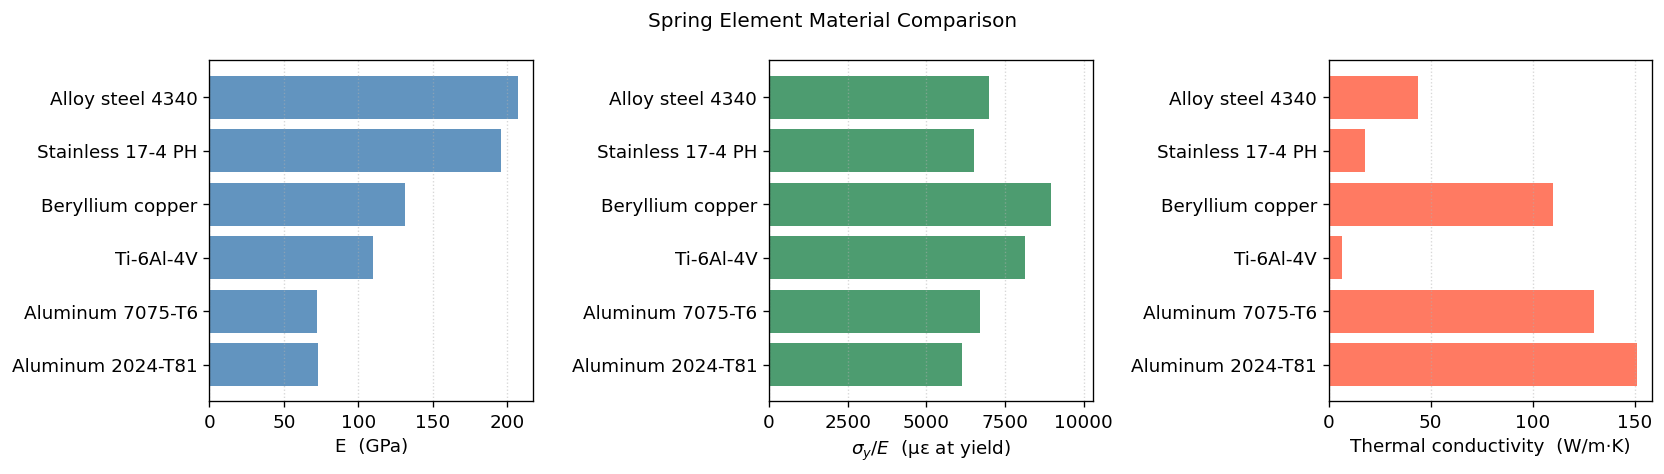

Lower E          -> thicker, more stable section for a given strain target.
Higher sigma_y/E -> more usable strain (signal) before yield: BeCu and Ti lead.
Higher k         -> gage self-heating carried away, smaller thermal gradients.


In [2]:
# Materials discussed in Chapter 41 (representative design values).
# Tuple columns: E (GPa), yield strength sigma_y (MPa), thermal conductivity k (W/m-K).
# The psi / ksi equivalents in the comments cross-reference Table 41.1 in the chapter.
MATERIALS = {
    'Alloy steel 4340':  (207, 1448,  44),   # 30 Mpsi, 210 ksi
    'Stainless 17-4 PH': (196, 1276,  18),   # 28.5 Mpsi, 185 ksi
    'Beryllium copper':  (131, 1172, 110),   # 19 Mpsi, 170 ksi (C17200, aged; Materion)
    'Ti-6Al-4V':         (110,  896, 6.7),   # 16 Mpsi, 130 ksi
    'Aluminum 7075-T6':  ( 72,  483, 130),   # 10.4 Mpsi, 70 ksi
    'Aluminum 2024-T81': ( 73,  448, 151),   # 10.6 Mpsi, 65 ksi
}

# The book includes this exact file — do not rename it.
FIG_PATH = OUT_DIR / 'fig41_nb1_material_comparison_transducer.png'
SAVE_DPI = 150


def elastic_strain_capacity_ue(sigma_y_mpa, E_gpa):
    """Usable elastic strain before yield, in microstrain.

    The figure of merit sigma_y / E is the largest strain — and therefore the
    largest bridge signal — the element can develop while staying elastic.
    With sigma_y in MPa (1e6 Pa) and E in GPa (1e9 Pa), the bare ratio
    sigma_y/E equals the true strain scaled by 1e3; multiplying by 1e3 rescales
    that to microstrain (strain x 1e6). BeCu and Ti lead on this metric.
    """
    return 1.0e3 * np.asarray(sigma_y_mpa, dtype=float) / np.asarray(E_gpa, dtype=float)


names = list(MATERIALS.keys())
E  = np.array([v[0] for v in MATERIALS.values()], dtype=float)   # GPa
sy = np.array([v[1] for v in MATERIALS.values()], dtype=float)   # MPa
k  = np.array([v[2] for v in MATERIALS.values()], dtype=float)   # W/m-K
strain_cap = elastic_strain_capacity_ue(sy, E)                   # microstrain at yield

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
panels = [
    (axes[0], E,          "E  (GPa)",                       'steelblue'),
    (axes[1], strain_cap, r"$\sigma_y/E$  (µε at yield)",   'seagreen'),
    (axes[2], k,          "Thermal conductivity  (W/m·K)",  'tomato'),
]
for ax, vals, label, color in panels:
    ax.barh(names, vals, color=color, alpha=0.85)
    ax.set_xlabel(label)
    ax.grid(True, axis='x', linestyle=':', alpha=0.5)
    ax.invert_yaxis()  # first material on top

axes[1].set_xlim(0, strain_cap.max() * 1.15)
plt.suptitle('Spring Element Material Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_PATH, bbox_inches='tight', dpi=SAVE_DPI)
plt.show()

print("Lower E          -> thicker, more stable section for a given strain target.")
print("Higher sigma_y/E -> more usable strain (signal) before yield: BeCu and Ti lead.")
print("Higher k         -> gage self-heating carried away, smaller thermal gradients.")

---
## Where to take this next

This comparison is a starting point, not a verdict — the chapter is explicit that the final choice also turns on hysteresis, modulus stability after heat treatment, fatigue, thermal expansion for the compensation scheme, and residual stress. A few concrete ways to build on it:

1. **Turn the depth-ratio argument into numbers.** Implement Eq. 41.1, $h=\sqrt{6FL/(\varepsilon_{\max} E b)}$, and Eq. 41.2, $h_1/h_2=\sqrt{E_2/E_1}$, as functions. Sweep rated load $F$ for each alloy at a fixed strain target and plot section depth $h$ versus capacity — you should recover the chapter's crossover, where aluminum's thickness advantage gives way to steel's yield strength somewhere around 1,000–5,000 lb.
2. **Quantify the three consequences of a thicker section.** The chapter shows that a fixed machining tolerance $\Delta h$ gives a depth error $\Delta h/h$ and a strain error of about $2\Delta h/h$, that conduction area scales as $h$, and that gage reinforcement scales with the gage layer's stiffness relative to the section, roughly $E_g t_g/(E_s h)$. Compute all three for the 5 N example (1.5 mm steel vs. 2.53 mm aluminum) and confirm that aluminum is reinforced about 1.7 times as much as steel ($E_s h$ is about 310 GPa$\cdot$mm in steel and 185 GPa$\cdot$mm in aluminum).
3. **Add a two-axis trade-off map.** Plot elastic strain capacity $\sigma_y/E$ against thermal conductivity, annotate each alloy, and shade the "self-heating penalty" corner where titanium and the PH stainless steels sit — making the design tension between signal and thermal management visible in one view.